In [12]:
import numpy as np
import gzip
import os
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [13]:
data_dir = os.path.join("assets", "MNIST", "raw")
filenames = ['train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
             't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz']
data = []

for filename in filenames:
    filepath = os.path.join(data_dir, filename)
    print("Loading", filepath)
    with gzip.open(filepath, 'rb') as f:
        if 'labels' in filename:
            data.append(np.frombuffer(f.read(), np.uint8, offset=8))
        else:
            data.append(np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28))

X_train, y_train, X_test, y_test = data

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

print("Data loaded successfully!")

Loading assets/MNIST/raw/train-images-idx3-ubyte.gz
Loading assets/MNIST/raw/train-labels-idx1-ubyte.gz
Loading assets/MNIST/raw/t10k-images-idx3-ubyte.gz
Loading assets/MNIST/raw/t10k-labels-idx1-ubyte.gz
Data loaded successfully!


In [14]:
def show_images(images, labels=None):
    pixels = images.reshape(-1, 28, 28)
    fig, axs = plt.subplots(
        ncols=len(images), nrows=1, figsize=(10, 3*len(images))
    )

    if len(images) == 1:
        axs = [axs]

    for i in range(len(images)):
        axs[i].imshow(pixels[i], cmap="gray")
        if labels is not None:
            axs[i].set_title(f"Label: {labels[i]}")

        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f"Index: {i}")
    
    fig.subplots_adjust(hspace=0.5)

    plt.show()

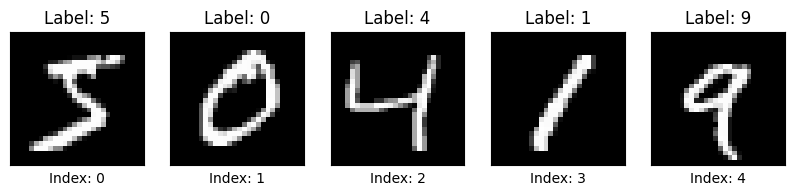

In [15]:
show_images(X_train[:5], y_train[:5])

In [16]:
class AutoEncoder(nn.Module):
    def __init__(self, num_hidden=8):
        super().__init__()
        self.num_hidden = num_hidden

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, self.num_hidden),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [17]:
learning_rate = 1e-3
batch_size = 64
n_epochs = 5

X_train = torch.from_numpy(X_train)

In [18]:
torch.manual_seed(42)

model = AutoEncoder(num_hidden=8)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

criterion = nn.MSELoss()

model.to(device)

train_loader = torch.utils.data.DataLoader(
    X_train, batch_size=batch_size, shuffle=True
)

In [19]:
num_epochs = 10
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        data = data.to(device)

        encoded, decoded = model(data)

        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        f"Epoch {epoch + 1}/{num_epochs}: loss={epoch_loss:.4f}"
    )

Epoch 1/10: loss=0.0425
Epoch 2/10: loss=0.0313
Epoch 3/10: loss=0.0281
Epoch 4/10: loss=0.0263
Epoch 5/10: loss=0.0255
Epoch 6/10: loss=0.0249
Epoch 7/10: loss=0.0244
Epoch 8/10: loss=0.0241
Epoch 9/10: loss=0.0237
Epoch 10/10: loss=0.0235


Original Images:


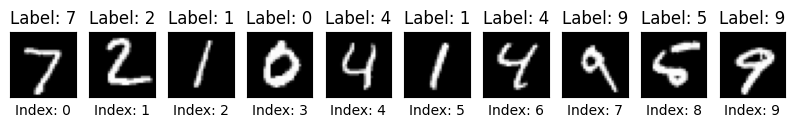

Reconstructed Images:


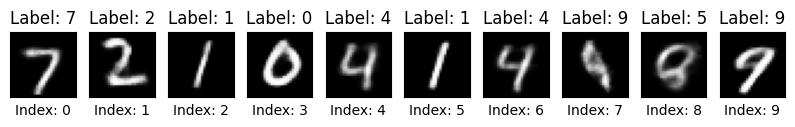

In [20]:
num_samples = 10

test_samples = X_test[:num_samples]
test_samples = torch.tensor(test_samples).to(device)
test_samples = test_samples.view(-1, 784)

model.eval()

with torch.no_grad():
    _, reconstructed = model(test_samples)

test_samples = test_samples.to('cpu')
reconstructed = reconstructed.to('cpu')
test_samples = test_samples.numpy().reshape(-1, 28, 28)
reconstructed = reconstructed.numpy().reshape(-1, 28, 28)

print("Original Images:")
show_images(test_samples, y_test[:num_samples])

print("Reconstructed Images:")
show_images(reconstructed, y_test[:num_samples])

/tmp/ipykernel_3986900/3992452657.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_samples = torch.tensor(X_train[:num_samples]).to(device)


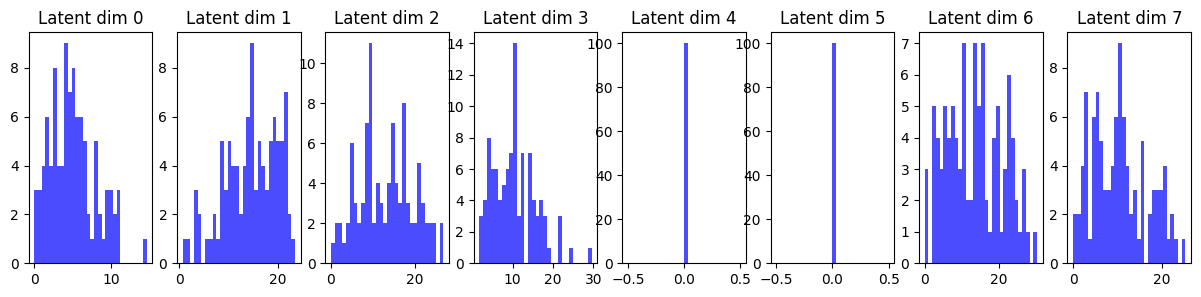

In [21]:
num_samples = 100
train_samples = torch.tensor(X_train[:num_samples]).to(device)

model.eval()
with torch.no_grad():
    encoded_samples, _ = model(train_samples)

encoded_samples = encoded_samples.to('cpu').numpy()

fig, axes = plt.subplots(1, model.num_hidden, figsize=(15, 3))
for i in range(model.num_hidden):
    axes[i].hist(encoded_samples[:, i], bins=30, alpha=0.7, color='blue')
    axes[i].set_title(f"Latent dim {i}")

plt.show()

Random Samples from Latent Space:
tensor([[ 0.1412, -0.3256, -1.6956, -0.1182, -1.2858,  0.0066,  0.7281, -0.0879],
        [ 1.2656,  0.6386, -0.7725,  2.0677, -1.2194, -1.5989, -0.5797, -1.2600],
        [-0.8414, -1.5470, -2.1165,  1.0883, -0.0426, -1.5287,  0.0564,  1.5010],
        [ 1.3471, -0.9487, -0.8305, -0.4721, -3.3433,  0.1195, -0.2138,  1.9082],
        [ 0.5697,  0.3489, -0.7282, -1.9471,  0.8564, -0.2858,  0.8110, -2.2207],
        [ 1.9961, -0.1089,  0.5136,  1.1622,  0.3075, -1.5676, -0.4162,  1.1604],
        [-0.0295,  0.4903, -1.4310,  0.2893,  0.3361,  2.2311, -1.0643, -0.0640],
        [-0.0885,  0.0284, -3.0998, -1.3882, -0.7730, -0.6171, -1.1044,  1.7194],
        [ 0.6078,  0.5068, -1.4588,  1.3093, -0.9676,  0.8233,  0.7020,  0.4185],
        [ 0.1826, -0.5999, -0.9032, -0.8520, -0.8676,  0.3316, -0.9497, -0.8548]],
       device='cuda:0')
Generated Images from Latent Space:


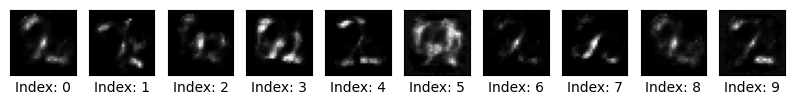

In [25]:
num_samples = 10
latent_dim = model.num_hidden
encoded_samples = torch.randn(num_samples, latent_dim).to(device)

print("Random Samples from Latent Space:")
print(encoded_samples)

model.eval()
with torch.no_grad():
    generated_images = model.decoder(encoded_samples)

generated_images = generated_images.to('cpu').numpy().reshape(-1, 28, 28)

print("Generated Images from Latent Space:")
show_images(generated_images)

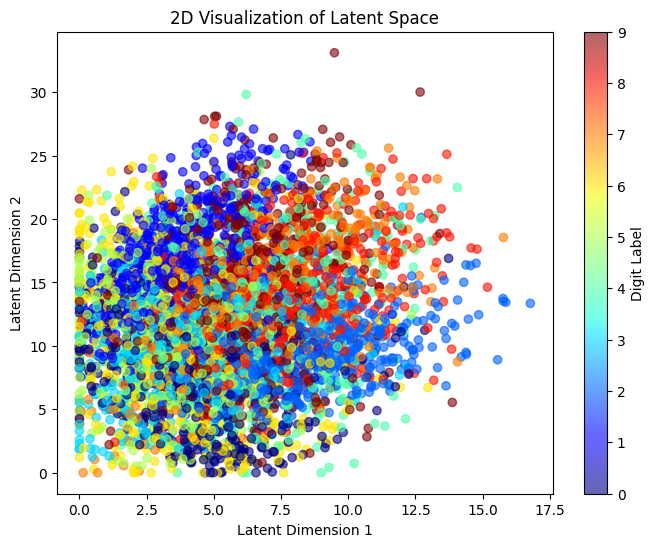

In [23]:
num_samples = 5000test_samples = torch.tensor(X_test[:num_samples]).to(device)test_labels = y_test[:num_samples]# 可选择维度x_dim = 0  # X轴维度 (0-7)y_dim = 1  # Y轴维度 (0-7)model.eval()with torch.no_grad():    encoded_samples, _ = model(test_samples)encoded_samples = encoded_samples.to('cpu').numpy()latent_x = encoded_samples[:, x_dim]latent_y = encoded_samples[:, y_dim]plt.figure(figsize=(8, 6))scatter = plt.scatter(latent_x, latent_y, c=test_labels, cmap="jet", alpha=0.6)plt.colorbar(scatter, label="Digit Label")plt.title(f"2D Visualization of Latent Space (dim {x_dim} vs dim {y_dim})")plt.xlabel(f"Latent Dimension {x_dim}")plt.ylabel(f"Latent Dimension {y_dim}")plt.show()

Generated Images with One Latent Dimension Changed:


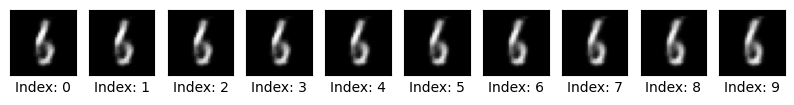

In [ ]:
latent_dim = model.num_hiddenbase_vector = torch.randn(latent_dim).to(device)*4+9# 可选择扫掠维度sweep_dim = 0  # 要扫掠的维度 (0-7)num_samples = 10change_values = torch.linspace(-1, 1, num_samples).to(device)encoded_samples = torch.stack([    base_vector.clone().detach() for _ in range(num_samples)])for i in range(num_samples):    encoded_samples[i, sweep_dim] = change_values[i]model.eval()with torch.no_grad():    generated_images = model.decoder(encoded_samples)generated_images = generated_images.to('cpu').numpy().reshape(-1, 28, 28)print(f"Generated Images with Latent Dimension {sweep_dim} Changed:")show_images(generated_images)

In [ ]:
# 二维潜空间操场：7x7 网格扫描两个维度latent_dim = model.num_hidden# 以当前 latent 向量为基底 (可以改为随机或零向量)base_latent = torch.randn(latent_dim).to(device) * 4 + 9# 选择要扫描的两个维度dim_x = 0  # X轴维度 (列)dim_y = 1  # Y轴维度 (行)grid_size = 7x_values = torch.linspace(-2.5, 2.5, grid_size)y_values = torch.linspace(-2.5, 2.5, grid_size)# 生成 7x7 个 latent 向量encoded_samples = []for i in range(grid_size):    for j in range(grid_size):        latent = base_latent.clone()        latent[dim_x] = x_values[j]        latent[dim_y] = y_values[i]        encoded_samples.append(latent)encoded_samples = torch.stack(encoded_samples)model.eval()with torch.no_grad():    generated_images = model.decoder(encoded_samples)generated_images = generated_images.to('cpu').numpy().reshape(-1, 28, 28)# 绘制 7x7 网格fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))for idx, ax in enumerate(axes.flat):    ax.imshow(generated_images[idx], cmap='gray')    ax.axis('off')plt.suptitle(f'2D Latent Playground: dim {dim_x} (x) vs dim {dim_y} (y)', fontsize=14)plt.tight_layout()plt.show()print(f"基底 latent 向量 (前4维): {base_latent[:4].cpu().numpy()}")